#Seasonal and Regional Patterns in Malaria Incidence accross Ghana
#capstone project- full analysis
# requirements are data sets, numpy, pandas, matplotlip,statsmodel


In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

In [ ]:
#importing dataset
from google.colab import files
uploaded = files.upload()

Saving pone.0191707.s010 5.xlsx to pone.0191707.s010 5.xlsx


In [ ]:
plos_raw = pd.read_excel("pone.0191707.s010 5.xlsx")
plos_raw.to_csv("pone.0191707.s010 5.csv", index=False)
df = pd.read_csv("pone.0191707.s010 5.csv")
df

,year,month,zone,uncomplicated_malaria_comfirmed
0,2008,1,savannah,8921
1,2008,2,savannah,8562
2,2008,3,savannah,6102
3,2008,4,savannah,6058
4,2008,5,savannah,6411
...,...,...,...,...
319,2016,8,coastal,106229
320,2016,9,coastal,94587
321,2016,10,coastal,121991
322,2016,11,coastal,110910


In [ ]:
df.dtypes

,0
year,int64
month,int64
zone,object
uncomplicated_malaria_comfirmed,int64


In [ ]:
#inspecting dataset
df.head()

,year,month,zone,uncomplicated_malaria_comfirmed
0,2008,1,savannah,8921
1,2008,2,savannah,8562
2,2008,3,savannah,6102
3,2008,4,savannah,6058
4,2008,5,savannah,6411


In [ ]:
df.tail()

,year,month,zone,uncomplicated_malaria_comfirmed
319,2016,8,coastal,106229
320,2016,9,coastal,94587
321,2016,10,coastal,121991
322,2016,11,coastal,110910
323,2016,12,coastal,89851


In [ ]:
df.shape

(324, 4)

In [ ]:
df.columns

Index(['year', 'month', 'zone', 'uncomplicated_malaria_comfirmed'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   year                             324 non-null    int64 
 1   month                            324 non-null    int64 
 2   zone                             324 non-null    object
 3   uncomplicated_malaria_comfirmed  324 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 10.3+ KB


In [ ]:
#checking for missing values
df.isnull()

,year,month,zone,uncomplicated_malaria_comfirmed
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
319,False,False,False,False
320,False,False,False,False
321,False,False,False,False
322,False,False,False,False


In [ ]:
df.isnull().sum()

,0
year,0
month,0
zone,0
uncomplicated_malaria_comfirmed,0


In [ ]:
#looking for duplicates
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
319,False
320,False
321,False
322,False


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#handling missing data. Since there is no missing data we maintain data as it is
df.dropna(inplace=True)

In [ ]:
#checking for typos
print(df['zone'].unique())

['savannah' 'forest' 'coastal']


In [ ]:
print(df['month'].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [ ]:
print(df['year'].unique())

[2008 2009 2010 2011 2012 2013 2014 2015 2016]


In [ ]:
df.describe()

,year,month,uncomplicated_malaria_comfirmed
count,324.000000,324.000000,324.000000
mean,2012.000000,6.500000,70075.314815
std,2.585983,3.457392,62730.803263
min,2008.000000,1.000000,2471.000000
25%,2010.000000,3.750000,26478.500000
50%,2012.000000,6.500000,42536.500000
75%,2014.000000,9.250000,93558.000000
max,2016.000000,12.000000,284428.000000


In [ ]:
df['zone'].value_counts()

,count
zone,
savannah,108
forest,108
coastal,108


In [ ]:
# answering data questions
#how does the seasonal pattern differ across zones and year?


In [ ]:
seasonal_avg = df_malaria_incidence.groupby(['zone', 'month'])['uncomplicated_malaria_comfirmed'].mean()
seasonal_avg_df = seasonal_avg.reset_index()
seasonal_pivot = seasonal_avg_df.pivot(index='month', columns='zone', values='uncomplicated_malaria_comfirmed')
seasonal_averages = seasonal_pivot

In [ ]:
print(seasonal_averages)

zone        coastal         forest      savannah
month                                           
1      37305.888889  100608.888889  27038.444444
2      35484.888889   93792.444444  26732.111111
3      35735.666667   96933.000000  24577.888889
4      40102.111111  114314.555556  24395.555556
5      43283.333333  134221.888889  29907.333333
6      47140.555556  145926.444444  38867.666667
7      49855.333333  150945.888889  52510.666667
8      44389.222222  136860.777778  62073.333333
9      38112.444444  124541.333333  67356.666667
10     42940.333333  140337.888889  78686.666667
11     42533.666667  141388.666667  53709.777778
12     38346.666667  126696.555556  35056.777778


In [ ]:
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
colors = {'savannah' : 'blue', 'forest':'yellow', 'coastal': 'red'}

In [ ]:
print(seasonal_averages.index)

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int64', name='month')


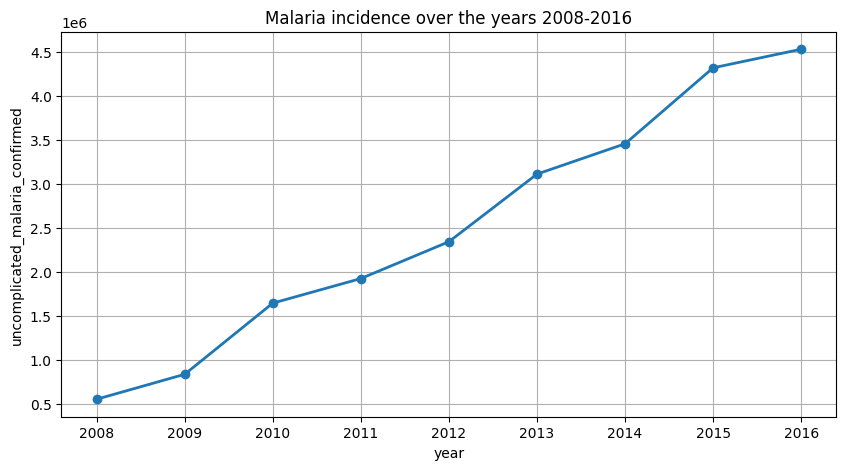

In [ ]:
#trend over time
yearly_data = df.groupby('year')['uncomplicated_malaria_comfirmed'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(yearly_data['year'], yearly_data['uncomplicated_malaria_comfirmed'], marker='o', linewidth=2, label='yearly')
plt.title('Malaria incidence over the years 2008-2016')
plt.xlabel('year')
plt.ylabel('uncomplicated_malaria_confirmed')
plt.grid(True)
plt.show()

#there is a significant increase trend in malaria overtime.

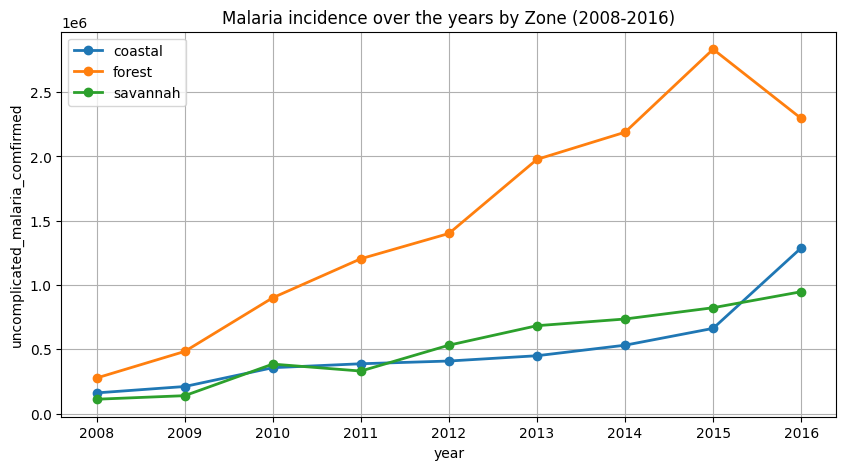

In [ ]:
yearly_zone = df.groupby(['year', 'zone'])['uncomplicated_malaria_comfirmed'].sum().reset_index()

plt.figure(figsize = (10, 5))
for zone_name in yearly_zone['zone'].unique():
    zone_data = yearly_zone[yearly_zone['zone'] == zone_name]
    plt.plot(zone_data['year'], zone_data['uncomplicated_malaria_comfirmed'], marker='o', linewidth=2, label=zone_name)

plt.title('Malaria incidence over the years by Zone (2008-2016)')
plt.xlabel('year')
plt.ylabel('uncomplicated_malaria_comfirmed')
plt.grid(True)
plt.legend()
plt.show()

# Forest zone marked by yellow carries more than 50% of malaria incidence in Ghana. Savannah and coastal are similar. All zones show an increase in malaria trends but forest increases steeply more.This proves more resources should be meted out to forest to target the elimination and eradiccation of malaria.

In [ ]:
# Has incidence shown a significance trend over time? plotting seasonal pattern

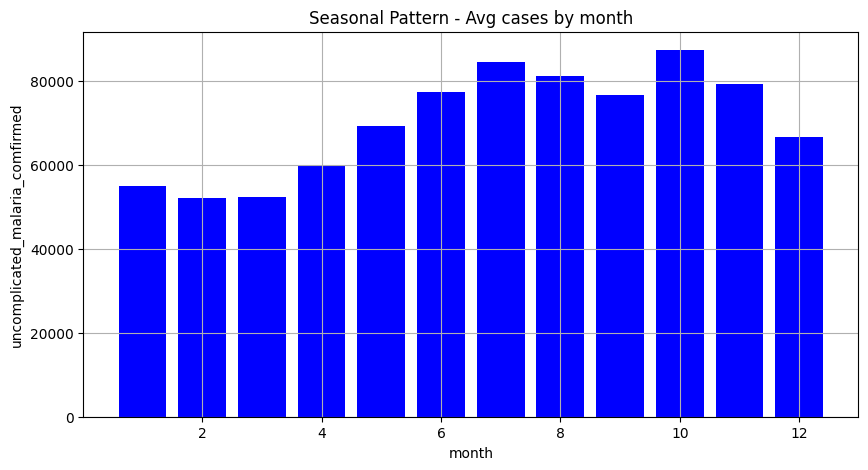

In [ ]:
monthly = df.groupby('month')['uncomplicated_malaria_comfirmed'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(monthly['month'], monthly['uncomplicated_malaria_comfirmed'], color='blue')
plt.title('Seasonal Pattern - Avg cases by month')
plt.xlabel('month')
plt.ylabel('uncomplicated_malaria_comfirmed')
plt.grid(True)
plt.show()

# malaria peaks during the rainy season that is june, july and october-november indicating that malaria is highly seasonal. This is because rainfall creates breeding sites for malaria causing female anopheles mosquito. In october however, although rainfall stops, these breeding sites like puddles still remain.

In [ ]:
#BUILDING A MACHINE LEARNING MODEL
#MACHINE LEARNING QUESTION ; Predict the number of confirmed malaria cases based on ecological zone and month
#type: regression(we are predicting case counts/ numerical). Random regression because data is not a straight line and zone is not a number
#input: zone, month, year.
#output: number of cases/ case counts

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('pone.0191707.s010 5.csv')
df.head()

,year,month,zone,uncomplicated_malaria_comfirmed
0,2008,1,savannah,8921
1,2008,2,savannah,8562
2,2008,3,savannah,6102
3,2008,4,savannah,6058
4,2008,5,savannah,6411


In [ ]:
#using label encoder for zone to translate words to numbers since machine learning only understands numbers.
#converting zones to numbers
#coastal=0, forest=1, savannah=2

In [ ]:
le = LabelEncoder()
df['zone_encoded'] = le.fit_transform(df['zone'])
print("forest, coastal, savannah have become numbers:")
print(df[['zone', 'zone_encoded']].head())

forest, coastal, savannah have become numbers:
       zone  zone_encoded
0  savannah             2
1  savannah             2
2  savannah             2
3  savannah             2
4  savannah             2


In [ ]:
# what I know and what I want to guess. I want to know month, year, and zone. And I want to guess number of cases.

x=df[['month', 'year', 'zone_encoded']]
y=df['uncomplicated_malaria_comfirmed']

In [ ]:
print(x)

     month  year  zone_encoded
0        1  2008             2
1        2  2008             2
2        3  2008             2
3        4  2008             2
4        5  2008             2
..     ...   ...           ...
319      8  2016             0
320      9  2016             0
321     10  2016             0
322     11  2016             0
323     12  2016             0

[324 rows x 3 columns]


In [ ]:
print(y)

0        8921
1        8562
2        6102
3        6058
4        6411
        ...  
319    106229
320     94587
321    121991
322    110910
323     89851
Name: uncomplicated_malaria_comfirmed, Length: 324, dtype: int64


#x is the year, month and zone and y shows how many people got malaria in the year, zone and month.

In [ ]:
#dividing into 2. Test and train. 80% to test and 20% train

In [ ]:
X_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
print(X_train.head())
print(x_test.head())
print(y_train.head())
print(y_test.head())

(259, 3)
(65, 3)
(259,)
(65,)
     month  year  zone_encoded
73       2  2014             2
181      2  2014             1
17       6  2009             2
24       1  2010             2
146      3  2011             1
     month  year  zone_encoded
132      1  2010             1
108      1  2008             1
137      6  2010             1
9       10  2008             2
180      1  2014             1
73      39558
181    133372
17      10745
24       8386
146     85858
Name: uncomplicated_malaria_comfirmed, dtype: int64
132     42386
108     25675
137    104644
9        6930
180    110255
Name: uncomplicated_malaria_comfirmed, dtype: int64


In [ ]:
#Training and modeling
#training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(model.score(x_test, y_test))

0.9489945819534614


#prediction

In [ ]:
future = [[6, 2026, 1]]
guess = model.predict(future)
print(f"Predicted cases: {guess}")

Predicted cases: [227202.73]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
pred = model.predict(x_test)
print(pred)

[ 42098.51  16068.05  84865.73  14146.87 147305.72  40384.07  11509.44
 230799.29  30365.72  87242.08 174654.64 120959.62  14475.73  39951.46
 215235.58  50045.56  48349.48  22391.4   12818.97  10312.95 102711.18
  33146.73  37969.8   88226.2  121145.44 101341.31 227202.73  65249.11
  34884.19 117484.97  75513.79 170933.62  30512.44 194111.36  50699.68
 192333.4   53462.68  52650.47  44170.9  134885.33 163918.09  40799.97
  58537.54  37512.04  44063.31  50547.36 169244.77  43981.47  60138.95
   4943.63  37248.7   16108.74  13776.11  36805.82  40121.88  36975.65
  39807.19  32076.56   5750.98  24350.39 126088.29  14783.07  37052.86
  99187.44  30875.34]


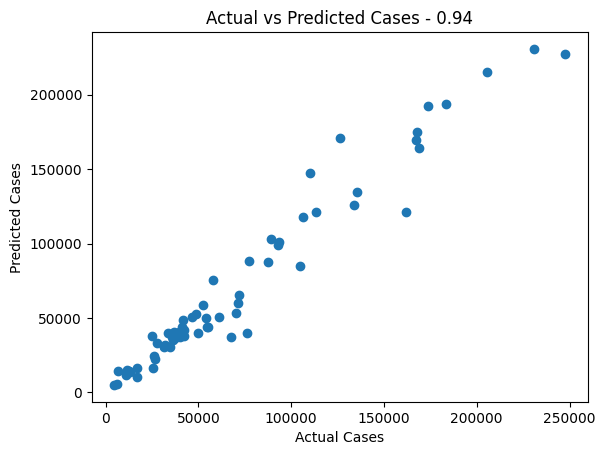

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, pred)
plt.xlabel('Actual Cases')
plt.ylabel('Predicted Cases')
plt.title('Actual vs Predicted Cases - 0.94')
plt.show()

# the scatter plot shows actual cases on the x axis and predicted cases on the y axis. Forest model is 94% accurate at predicting malaria.

#regression evaluation plot to check how close the predicted malaria cases are to the actual cases.

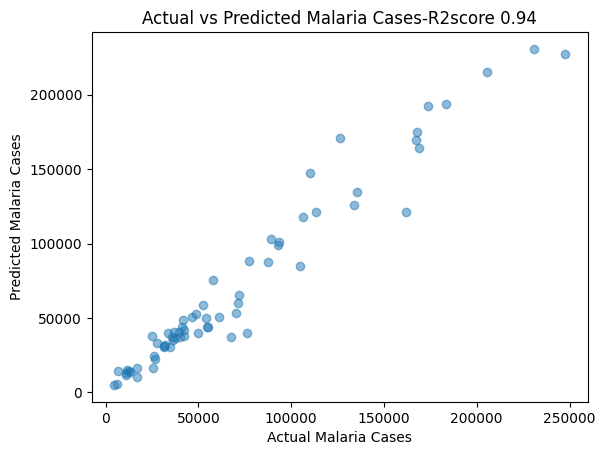

In [ ]:
#adding labels to plot
plt.xlabel("Actual Malaria Cases")
plt.ylabel("Predicted Malaria Cases")
plt.title("Actual vs Predicted Malaria Cases-R2score 0.94")
plt.scatter(y_test, pred, alpha=0.5)

#regression evaluation plot. x asis shows actual cases and y axis shows predicted cases. Correlation is 94%. Each dot is a month. Dots are close in line with correlation 0.94 which means random forest predicts malaria cases well from zone to month.

In [ ]:
import joblib
joblib.dump(model, 'malaria_model joblib')

['malaria_model joblib']

#powerBi

In [ ]:
import pandas as pd
results = pd.DataFrame({'Real_cases': y_test, 'Predicted_cases': pred})
results.to_csv('results.csv', index=False)

In [ ]:
df.to_csv('capstone_dashboard.csv', index=False)